# Detección de Edificios en xBD con Faster R-CNN

**Dataset:** xBD_UC3M — imágenes de satélite post-disaster, 1024×1024 px  
**Modelo:** Faster R-CNN con backbone ResNet-50 FPN (torchvision_05)  
**Tarea:** Detectar edificios (1 clase: building) sobre la imagen completa

## Estadísticas del dataset (train)
| Split | Imágenes | Desastres |
|-------|----------|-----------|
| train | 256      | 7         |
| val   | 45       | 4         |
| test  | 63       | 5         |

**Tamaño de los edificios en px:**  
- p5=9 · p25=17 · mediana=26 · p75=36 · p95=51 · máx=436  
- Aspecto (w/h): mediana=1.0, rango [0.55, 1.82] → edificios casi cuadrados

## 0. Setup

In [1]:
import sys
import os

# torchvision_05 y engine.py se encuentran en el directorio del Proyecto 2B
PR2B_DIR = '/home/a472259/uni25-26/VA/VA_Pr2B_ObjectDetection_2025_2026'
if PR2B_DIR not in sys.path:
    sys.path.insert(0, PR2B_DIR)

import json
import csv
import time
import glob
import numpy as np
import cv2
import tifffile
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
from torch.utils.data import Dataset, DataLoader
from natsort import natsorted
from shapely.wkt import loads as wkt_loads
from shapely.geometry import Polygon

import torchvision_05
import torchvision_05.models.detection
from torchvision_05.models.detection import fasterrcnn_resnet50_fpn
from torchvision_05.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision_05.models.detection.rpn import AnchorGenerator

from engine import train_one_epoch, eval_one_epoch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('PyTorch:', torch.__version__)

Device: cuda
PyTorch: 2.11.0+cu128


## 1. Dataset: `xBDDetectionDataset`

### Formato de las anotaciones xBD
Cada JSON (`*_post_disaster.json`) tiene la estructura:
```
data['features']['xy']  →  lista de features
feature['wkt']          →  polígono en WKT (coordenadas píxel)
feature['properties']['feature_type']  →  'building'
feature['properties']['subtype']       →  'no-damage' | 'minor-damage' | 'major-damage' | 'destroyed'
```

Para detección, convertimos cada polígono WKT → bounding box `[x_min, y_min, x_max, y_max]`  
y asignamos **label=1** a todos los edificios (fondo=0).

In [2]:
IMG_SIZE = 1024  # tamaño de las imágenes xBD


class xBDDetectionDataset(Dataset):
    """
    Dataset para deteccion de edificios en xBD con Faster R-CNN.

    Devuelve:
      image   : FloatTensor [3, H, W] en rango [0, 1]
      target  : dict con 'boxes' [N,4], 'labels' [N], 'image_id' [1], 'area' [N]
      img_path: str (para visualización)

    Etiquetas:
      0 → fondo (reservado internamente por Faster R-CNN)
      1 → edificio (building)
    """

    def __init__(self, data_dir, split, max_size=0):
        """
        Args:
            data_dir : raiz del dataset (contiene train/, val/, test/)
            split    : str o lista de str, e.g. 'train' o ['train', 'val']
            max_size : si > 0, limita el número de imágenes (útil para debug)
        """
        if isinstance(split, str):
            split = [split]
        self.samples = []  # lista de (img_path, lbl_path)

        for s in split:
            split_dir = os.path.join(data_dir, s)
            for disaster in natsorted(os.listdir(split_dir)):
                img_dir = os.path.join(split_dir, disaster, 'images')
                lbl_dir = os.path.join(split_dir, disaster, 'labels')
                post_imgs = natsorted([f for f in os.listdir(img_dir) if 'post' in f])
                post_lbls = natsorted([f for f in os.listdir(lbl_dir) if 'post' in f])
                for img_f, lbl_f in zip(post_imgs, post_lbls):
                    self.samples.append((
                        os.path.join(img_dir, img_f),
                        os.path.join(lbl_dir, lbl_f)
                    ))

        if max_size > 0:
            rng = np.random.RandomState(42)
            idx = rng.permutation(len(self.samples))[:max_size]
            self.samples = [self.samples[i] for i in idx]

        print(f'[xBDDetectionDataset] split={split}  imágenes={len(self.samples)}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, lbl_path = self.samples[idx]

        # --- Imagen ---
        image = tifffile.imread(img_path)  # H×W×C (uint8 o uint16)
        if image.ndim == 2:
            image = np.stack([image] * 3, axis=-1)
        elif image.shape[2] > 3:
            image = image[:, :, :3]  # descartar canales extra (NIR, etc.)
        if image.shape[:2] != (IMG_SIZE, IMG_SIZE):
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        # Normalizar a [0, 1].
        # xBD: imágenes uint16 con valores reales en 0-510 (no 0-65535).
        # Dividir entre np.iinfo(uint16).max=65535 deja los píxeles en ~0.008,
        # haciendo que el RPN produzca propuestas NaN y falle en batched_nms CUDA.
        # Se usa 255 (igual que en el Proyecto 1) + clip para garantizar [0, 1].
        image = np.clip(image.astype(np.float32) / 255.0, 0.0, 1.0)
        image = torch.from_numpy(image.transpose(2, 0, 1))  # → C×H×W

        # --- Anotaciones ---
        with open(lbl_path) as f:
            data = json.load(f)

        boxes = []
        for feat in data['features']['xy']:
            if 'wkt' not in feat:
                continue
            if feat['properties'].get('feature_type') != 'building':
                continue
            try:
                geom = wkt_loads(feat['wkt'])
                if not geom.is_valid or geom.is_empty:
                    continue
                coords = np.array(geom.exterior.coords)
                x_min, y_min = coords.min(axis=0)
                x_max, y_max = coords.max(axis=0)
                # Clamp a los límites de la imagen
                x_min = max(0.0, float(x_min))
                y_min = max(0.0, float(y_min))
                x_max = min(float(IMG_SIZE), float(x_max))
                y_max = min(float(IMG_SIZE), float(y_max))
                # Descartar cajas degeneradas (ancho o alto < 2 px)
                if (x_max - x_min) > 1.0 and (y_max - y_min) > 1.0:
                    boxes.append([x_min, y_min, x_max, y_max])
            except Exception:
                continue

        if boxes:
            boxes_t  = torch.as_tensor(boxes, dtype=torch.float32)          # [N, 4]
            labels_t = torch.ones(len(boxes), dtype=torch.int64)            # label=1 (edificio)
            area_t   = (boxes_t[:, 3] - boxes_t[:, 1]) * (boxes_t[:, 2] - boxes_t[:, 0])
        else:
            boxes_t  = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,),   dtype=torch.int64)
            area_t   = torch.tensor([0.0])

        target = {
            'boxes':    boxes_t,
            'labels':   labels_t,
            'image_id': torch.tensor([idx]),
            'area':     area_t,
        }

        return image, target, img_path


def collate_fn(batch):
    """Faster R-CNN necesita lista de imágenes y lista de targets."""
    images, targets, paths = zip(*batch)
    return list(images), list(targets), list(paths)

In [3]:
DATA_DIR = 'data/xBD_UC3M'

dataset_train = xBDDetectionDataset(DATA_DIR, 'train')
dataset_val   = xBDDetectionDataset(DATA_DIR, 'val')
dataset_test  = xBDDetectionDataset(DATA_DIR, 'test')

[xBDDetectionDataset] split=['train']  imágenes=256
[xBDDetectionDataset] split=['val']  imágenes=45
[xBDDetectionDataset] split=['test']  imágenes=63


In [4]:
# Verificar un ejemplo
img, tgt, path = dataset_train[0]
print('Imagen shape:', img.shape, '  dtype:', img.dtype, '  rango:', img.min().item(), img.max().item())
print('Num edificios:', len(tgt['boxes']))
print('Primeras 3 cajas:', tgt['boxes'][:3])
print('Etiquetas:', tgt['labels'][:3])

Imagen shape: torch.Size([3, 1024, 1024])   dtype: torch.float32   rango: 0.01568627543747425 1.0
Num edificios: 185
Primeras 3 cajas: tensor([[2.0898e+02, 6.1024e-03, 2.5300e+02, 2.4607e+01],
        [2.1521e+02, 3.6514e+01, 2.4933e+02, 7.4572e+01],
        [2.0485e+02, 8.1443e+01, 2.4272e+02, 1.3078e+02]])
Etiquetas: tensor([1, 1, 1])


## 2. Análisis de Anchor Sizes (basado en los datos reales)

Los edificios en xBD son **mucho más pequeños** que los objetos de PASCAL VOC/COCO.  
Los anchor sizes por defecto de Faster R-CNN `[32, 64, 128, 256, 512]` no son óptimos.

In [5]:
print('Analizando tamaños de edificios en el conjunto de entrenamiento...')
widths, heights = [], []

for _, tgt, _ in dataset_train:
    for box in tgt['boxes']:
        x_min, y_min, x_max, y_max = box.tolist()
        widths.append(x_max - x_min)
        heights.append(y_max - y_min)

widths  = np.array(widths)
heights = np.array(heights)
sizes   = np.sqrt(widths * heights)  # lado del cuadrado de área equivalente
aspects = widths / heights

print(f'\nEdificios en train: {len(widths):,}')
print(f"\nAncho (px):      p5={np.percentile(widths,5):.1f}  p25={np.percentile(widths,25):.1f}  "
      f"med={np.median(widths):.1f}  p75={np.percentile(widths,75):.1f}  p95={np.percentile(widths,95):.1f}")
print(f"Alto  (px):      p5={np.percentile(heights,5):.1f}  p25={np.percentile(heights,25):.1f}  "
      f"med={np.median(heights):.1f}  p75={np.percentile(heights,75):.1f}  p95={np.percentile(heights,95):.1f}")
print(f"Sqrt(área) (px): p5={np.percentile(sizes,5):.1f}  p25={np.percentile(sizes,25):.1f}  "
      f"med={np.median(sizes):.1f}  p75={np.percentile(sizes,75):.1f}  p95={np.percentile(sizes,95):.1f}")
print(f"Aspecto (w/h):   p5={np.percentile(aspects,5):.2f}  med={np.median(aspects):.2f}  p95={np.percentile(aspects,95):.2f}")

Analizando tamaños de edificios en el conjunto de entrenamiento...

Edificios en train: 64,078

Ancho (px):      p5=9.0  p25=17.0  med=26.0  p75=36.3  p95=51.1
Alto  (px):      p5=9.0  p25=17.4  med=25.7  p75=36.1  p95=50.9
Sqrt(área) (px): p5=9.4  p25=17.5  med=26.3  p75=35.5  p95=47.9
Aspecto (w/h):   p5=0.55  med=1.00  p95=1.82


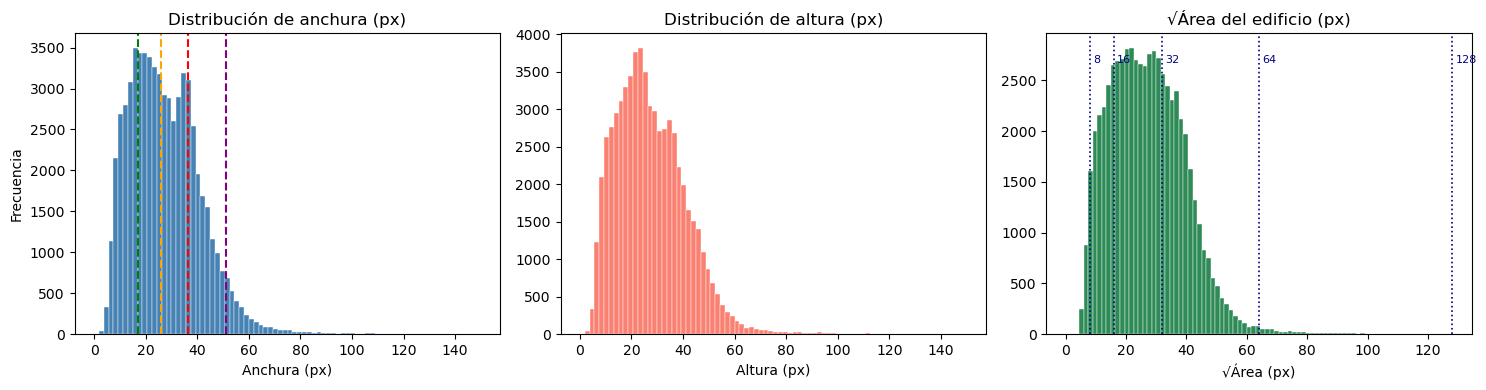


→ Anchor sizes recomendados: (8, 16, 32, 64, 128) px
→ Aspect ratios recomendados: (0.5, 1.0, 2.0)  (edificios cuadrados/rectangulares)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths,  bins=80, range=(0, 150), color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Distribución de anchura (px)')
axes[0].set_xlabel('Anchura (px)'); axes[0].set_ylabel('Frecuencia')
for p, c in zip([np.percentile(widths,25), np.median(widths), np.percentile(widths,75), np.percentile(widths,95)],
                ['green','orange','red','purple']):
    axes[0].axvline(p, color=c, linestyle='--', linewidth=1.5)

axes[1].hist(heights, bins=80, range=(0, 150), color='salmon',   edgecolor='white', linewidth=0.3)
axes[1].set_title('Distribución de altura (px)')
axes[1].set_xlabel('Altura (px)')

axes[2].hist(sizes,   bins=80, range=(0, 120), color='seagreen', edgecolor='white', linewidth=0.3)
axes[2].set_title('√Área del edificio (px)')
axes[2].set_xlabel('√Área (px)')

# Marcar los anchor sizes propuestos
anchor_sizes = [8, 16, 32, 64, 128]
for a in anchor_sizes:
    axes[2].axvline(a, color='navy', linestyle=':', linewidth=1.2)
    axes[2].text(a+1, axes[2].get_ylim()[1]*0.9, str(a), fontsize=8, color='navy')

plt.tight_layout()
plt.savefig('anchor_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('\n→ Anchor sizes recomendados: (8, 16, 32, 64, 128) px')
print('→ Aspect ratios recomendados: (0.5, 1.0, 2.0)  (edificios cuadrados/rectangulares)')

## 3. Modelo: Faster R-CNN con anchors personalizados

### Justificación de los anchors
| Percentil | √Área |
|-----------|-------|
| p5        | ~9 px |
| p25       | ~17 px|
| mediana   | ~26 px|
| p75       | ~36 px|
| p95       | ~51 px|

Los anchors `(8, 16, 32, 64, 128)` cubren el rango p5–p95 y están alineados con los 5 niveles del FPN.  
El anchor 128 captura los edificios grandes (>p95) y el 8 los más pequeños.

In [7]:
NUM_CLASSES = 2  # 0=fondo, 1=edificio
CLASS_NAMES = ['__background__', 'building']


def get_model(num_classes):
    # AnchorGenerator personalizado para objetos pequeños (imágenes de satélite)
    # 5 tamaños para los 5 niveles del FPN (P2–P6)
    anchor_generator = AnchorGenerator(
        sizes=((8,), (16,), (32,), (64,), (128,)),
        aspect_ratios=((0.5, 1.0, 2.0),) * 5
    )

    model = fasterrcnn_resnet50_fpn(
        pretrained=True,
        rpn_anchor_generator=anchor_generator,
        # min_size/max_size: Faster R-CNN redimensiona la imagen para que el lado
        # más corto sea min_size. Con 1024×1024 → escala 800/1024 ≈ 0.78
        min_size=800,
        max_size=1333,
    )

    # Reemplazar el clasificador: num_classes incluye el fondo
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


model = get_model(NUM_CLASSES)
model.to(DEVICE)
print('Modelo creado. Parámetros totales:',
      sum(p.numel() for p in model.parameters() if p.requires_grad))

Modelo creado. Parámetros totales: 41076761


## 4. DataLoaders

In [8]:
BATCH_SIZE  = 1   # torchvision_05/rpn.py:filter_proposals hace anchors.squeeze(0)[keep,:]
                  # Con batch>1: squeeze(0) no actúa (dim 0 != 1), keep tiene valores
                  # hasta ~2000 pero dim 0 solo tiene tamaño batch → OOB en GPU.
NUM_WORKERS = 4

data_loader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
)

data_loader_val = DataLoader(
    dataset_val,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
)

data_loader_test = DataLoader(
    dataset_test,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
)

print(f'Train batches: {len(data_loader_train)}')
print(f'Val   batches: {len(data_loader_val)}')
print(f'Test  batches: {len(data_loader_test)}')

Train batches: 256
Val   batches: 45
Test  batches: 63


## 5. Entrenamiento

Loop idéntico al Notebook 2, adaptado a xBD:  
- SGD + momentum=0.9 + weight_decay=0.0005  
- StepLR: reduce LR × 0.1 cada `step_size` épocas  
- Checkpoint por época; guarda `best_model.pth` con mejor F1

In [9]:
# Hiperparámetros
LR          = 0.001
MOMENTUM    = 0.9
WEIGHT_DECAY= 0.0005
NUM_EPOCHS  = 20
STEP_SIZE   = 8   # reducir LR en la época 8 y en la 16
GAMMA       = 0.1
TH_SCORE    = 0.5  # umbral de confianza para la evaluación
TH_IOU      = 0.5  # umbral IoU para considerar detección correcta

RESULT_DIR  = 'xbd_detection_results'
os.makedirs(RESULT_DIR, exist_ok=True)

# Pesos de las 4 pérdidas de Faster R-CNN
# [rpn_objectness, rpn_box_reg, roi_classifier, roi_box_reg]
LOSS_WEIGHTS = [1, 1, 1, 1]

params    = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

In [10]:
from external import bb_intersection_over_union
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix


def test_detection_model(
    model, dataloader, class_names, th_score, th_iou,
    result_dir, SAVE_OPT=False, SAVE_FULL=False, VERBOSE=False
):
    model.eval()
    since = time.time()

    n_classes     = len(class_names) - 1
    rel           = np.zeros(n_classes, dtype=int)
    ret_rel       = np.zeros(n_classes, dtype=int)
    ret           = 0
    y_true        = np.zeros((0,), dtype=int)
    y_pred        = np.zeros((0,), dtype=int)
    total_anchors = np.zeros((0, 4), dtype=np.float32)
    total_labels  = np.zeros((0,),   dtype=int)

    os.makedirs(result_dir, exist_ok=True)

    with torch.no_grad():
        for inputs, targets, paths in dataloader:
            inputs_d = [img.to(DEVICE) for img in inputs]
            preds    = model(inputs_d)

            for i in range(len(inputs)):
                gt_boxes  = targets[i]['boxes'].numpy()
                gt_labels = targets[i]['labels'].numpy()

                scores   = preds[i]['scores'].cpu().numpy()
                p_boxes  = preds[i]['boxes'].cpu().numpy()
                p_labels = preds[i]['labels'].cpu().numpy()

                keep     = scores > th_score
                p_boxes  = p_boxes[keep]
                p_labels = p_labels[keep]

                if 'anchors' in preds[i]:
                    anch = preds[i]['anchors'].cpu().numpy()[keep]
                    total_anchors = np.concatenate([total_anchors, anch], axis=0)
                    total_labels  = np.concatenate([total_labels,  p_labels], axis=0)

                ret += len(p_boxes)

                for j in range(1, len(class_names)):
                    rel[j-1] += np.sum(gt_labels == j)

                for j in range(gt_boxes.shape[0]):
                    if p_boxes.shape[0] == 0:
                        continue
                    ious = np.array([bb_intersection_over_union(gt_boxes[j], p_boxes[k])
                                     for k in range(p_boxes.shape[0])])
                    if ious.max() > th_iou:
                        best = ious.argmax()
                        cls  = gt_labels[j] - 1
                        ret_rel[cls] += 1
                        y_true = np.append(y_true, gt_labels[j])
                        y_pred = np.append(y_pred, p_labels[best])

                if SAVE_OPT or SAVE_FULL:
                    vis = (inputs[i].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
                    vis = cv2.cvtColor(vis, cv2.COLOR_RGB2BGR)
                    for box in gt_boxes:
                        cv2.rectangle(vis, (int(box[0]), int(box[1])),
                                      (int(box[2]), int(box[3])), (0, 255, 0), 1)
                    for box, lbl, sc in zip(p_boxes, p_labels, scores[keep]):
                        cv2.rectangle(vis, (int(box[0]), int(box[1])),
                                      (int(box[2]), int(box[3])), (0, 0, 255), 1)
                        cv2.putText(vis, f'{sc:.2f}', (int(box[0]), int(box[1])-2),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 0, 255), 1)
                    fname = os.path.basename(paths[i]).replace('.tif', '_det.jpg')
                    cv2.imwrite(os.path.join(result_dir, fname), vis)

            torch.cuda.empty_cache()

    precision_det = np.sum(ret_rel) / ret if ret > 0 else 0.0
    recall_det    = np.where(rel > 0, ret_rel / rel, 0.0)
    mean_recall   = np.mean(recall_det)
    f1_det = (2 * mean_recall * precision_det / (mean_recall + precision_det)
              if (mean_recall + precision_det) > 0 else 0.0)

    elapsed = time.time() - since
    print(f'Evaluación en {elapsed//60:.0f}m {elapsed%60:.0f}s')
    print(f'Detección → Precision: {precision_det:.4f}  Recall: {mean_recall:.4f}  F1: {f1_det:.4f}')
    print(f'GT total={rel.sum()}  TP={ret_rel.sum()}  Predicciones={ret}')

    labels_eval = list(range(1, len(class_names)))
    if len(y_true) > 0:
        prec_rec_marginal = precision_recall_fscore_support(
            y_true, y_pred, average=None, labels=labels_eval, zero_division=0)
        prec_rec_global = precision_recall_fscore_support(
            y_true, y_pred, average='macro', labels=labels_eval, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)
    else:
        prec_rec_marginal = prec_rec_global = cm = None

    return (precision_det, recall_det, f1_det, cm,
            prec_rec_global, prec_rec_marginal,
            total_anchors, total_labels)

print('test_detection_model definida correctamente.')

test_detection_model definida correctamente.


In [11]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Verifica que la normalización es correcta ANTES de lanzar el entrenamiento
img, tgt, _ = dataset_train[0]
print('Rango imagen:', img.min().item(), img.max().item())
# Debe mostrar algo como: 0.031  1.0


Rango imagen: 0.01568627543747425 1.0


In [12]:
log_path = os.path.join(RESULT_DIR, 'log.csv')
if os.path.exists(log_path):
    os.remove(log_path)

csv_file = open(log_path, 'w', newline='')
writer   = csv.writer(csv_file)
writer.writerow([
    'epoch',
    'train_total', 'train_rpn_box_reg', 'train_objectness', 'train_box_reg', 'train_classifier',
    'val_total',   'val_rpn_box_reg',   'val_objectness',   'val_box_reg',   'val_classifier',
    'precision', 'recall', 'f1'
])

best_f1 = 0.0

for epoch in range(NUM_EPOCHS):
    ckpt_path = os.path.join(RESULT_DIR, f'faster-rcnn-epoch{epoch}.pth')

    if not os.path.exists(ckpt_path):
        # --- Entrenamiento ---
        train_losses = train_one_epoch(
            model, optimizer, data_loader_train, DEVICE, LOSS_WEIGHTS, epoch, print_freq=50
        )
        scheduler.step()

        # --- Validación (pérdidas) ---
        val_losses = eval_one_epoch(
            model, data_loader_val, DEVICE, epoch, print_freq=20
        )

        # --- Evaluación con métricas de detección ---
        precision, recall, f1, *_ = test_detection_model(
            model, data_loader_val, CLASS_NAMES,
            TH_SCORE, TH_IOU, RESULT_DIR,
            SAVE_OPT=False, SAVE_FULL=False, VERBOSE=False
        )

        # --- Logging ---
        writer.writerow([
            epoch,
            train_losses['total'], train_losses['rpn_box_reg'],
            train_losses['objectness'], train_losses['box_reg'], train_losses['classifier'],
            val_losses['total'],   val_losses['rpn_box_reg'],
            val_losses['objectness'],   val_losses['box_reg'],   val_losses['classifier'],
            precision, np.mean(recall), f1
        ])
        csv_file.flush()

        print(f'[Epoch {epoch:02d}]  '
              f'Train={train_losses["total"]:.4f}  '
              f'Val={val_losses["total"]:.4f}  '
              f'Precision={precision:.3f}  Recall={np.mean(recall):.3f}  F1={f1:.3f}')

        # --- Checkpoint ---
        state = {
            'epoch':      epoch + 1,
            'state_dict': model.state_dict(),
            'optimizer':  optimizer.state_dict(),
            'scheduler':  scheduler.state_dict(),
        }
        torch.save(state, ckpt_path)
        if f1 > best_f1:
            torch.save(state, os.path.join(RESULT_DIR, 'best_model.pth'))
            best_f1 = f1
            print(f'  → Nuevo mejor modelo guardado (F1={best_f1:.4f})')
    else:
        # Reanudar desde checkpoint
        print(f'[Epoch {epoch:02d}] Cargando checkpoint...')
        ckpt = torch.load(ckpt_path)
        model.load_state_dict(ckpt['state_dict'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])

csv_file.close()
print(f'\nEntrenamiento finalizado. Mejor F1 en validación: {best_f1:.4f}')

/home/a472259/miniconda3/envs/VA_practica/lib/python3.10/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


(TRAIN) Epoch: [0]  [ 50/256]  eta: 0:00:21  lr: 0.000201  loss: 37.7198 (46.7913)  loss_classifier: 0.4265 (0.5442)  loss_box_reg: 0.0512 (0.0563)  loss_objectness: 0.0005 (2.5817)  loss_rpn_box_reg: 37.2695 (43.6091)  time: 0.0651  data: 0.0002  max mem: 1118
(TRAIN) Epoch: [0]  [100/256]  eta: 0:00:13  lr: 0.000397  loss: 55.1919 (50.6847)  loss_classifier: 0.1688 (0.3880)  loss_box_reg: 0.0276 (0.0528)  loss_objectness: 0.0001 (1.3038)  loss_rpn_box_reg: 54.7786 (48.9401)  time: 0.0652  data: 0.0002  max mem: 1118
(TRAIN) Epoch: [0]  [150/256]  eta: 0:00:08  lr: 0.000593  loss: 29.0504 (48.5610)  loss_classifier: 0.2957 (0.3312)  loss_box_reg: 0.0368 (0.0460)  loss_objectness: 0.1177 (0.8892)  loss_rpn_box_reg: 28.4540 (47.2946)  time: 0.0691  data: 0.0002  max mem: 1118
(TRAIN) Epoch: [0]  [200/256]  eta: 0:00:04  lr: 0.000788  loss: 36.3366 (45.9098)  loss_classifier: 0.3047 (0.3357)  loss_box_reg: 0.1887 (0.0755)  loss_objectness: 0.0049 (0.6723)  loss_rpn_box_reg: 35.7678 (44.8

/home/a472259/miniconda3/envs/VA_practica/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


  → Nuevo mejor modelo guardado (F1=0.0016)
(TRAIN) Epoch: [1]  [ 50/256]  eta: 0:00:15  lr: 0.001000  loss: 50.2167 (45.1345)  loss_classifier: 0.1606 (0.2392)  loss_box_reg: 0.0352 (0.1018)  loss_objectness: 0.0261 (0.0164)  loss_rpn_box_reg: 49.9502 (44.7771)  time: 0.0678  data: 0.0002  max mem: 1118
(TRAIN) Epoch: [1]  [100/256]  eta: 0:00:11  lr: 0.001000  loss: 39.7657 (46.9638)  loss_classifier: 0.1934 (0.2272)  loss_box_reg: 0.1052 (0.0989)  loss_objectness: 0.0065 (0.0108)  loss_rpn_box_reg: 39.3239 (46.6268)  time: 0.0673  data: 0.0002  max mem: 1118
(TRAIN) Epoch: [1]  [150/256]  eta: 0:00:07  lr: 0.001000  loss: 37.5950 (43.7789)  loss_classifier: 0.2152 (0.2498)  loss_box_reg: 0.1176 (0.1210)  loss_objectness: 0.0087 (0.0113)  loss_rpn_box_reg: 37.3598 (43.3967)  time: 0.0704  data: 0.0002  max mem: 1118
(TRAIN) Epoch: [1]  [200/256]  eta: 0:00:03  lr: 0.001000  loss: 51.6705 (45.5549)  loss_classifier: 0.2599 (0.2409)  loss_box_reg: 0.1358 (0.1148)  loss_objectness: 0.00

/home/a472259/miniconda3/envs/VA_practica/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


...

(TRAIN) Epoch: [18]  [ 50/256]  eta: 0:00:14  lr: 0.000010  loss: 56.8878 (57.6962)  loss_classifier: 0.1594 (0.1776)  loss_box_reg: 0.0419 (0.0567)  loss_objectness: 0.0015 (0.0014)  loss_rpn_box_reg: 56.5970 (57.4605)  time: 0.0643  data: 0.0002  max mem: 1119
(TRAIN) Epoch: [18]  [100/256]  eta: 0:00:10  lr: 0.000010  loss: 55.1668 (57.7290)  loss_classifier: 0.1261 (0.1681)  loss_box_reg: 0.0585 (0.0557)  loss_objectness: 0.0010 (0.0013)  loss_rpn_box_reg: 55.0449 (57.5040)  time: 0.0635  data: 0.0002  max mem: 1119
(TRAIN) Epoch: [18]  [150/256]  eta: 0:00:06  lr: 0.000010  loss: 54.4943 (56.7203)  loss_classifier: 0.1124 (0.1610)  loss_box_reg: 0.0403 (0.0519)  loss_objectness: 0.0010 (0.0013)  loss_rpn_box_reg: 54.3238 (56.5060)  time: 0.0646  data: 0.0002  max mem: 1119
(TRAIN) Epoch: [18]  [200/256]  eta: 0:00:03  lr: 0.000010  loss: 52.7366 (57.0199)  loss_classifier: 0.1428 (0.1591)  loss_box_reg: 0.0504 (0.0510)  loss_objectness: 0.0013 (0.0013)  loss_rpn_box_reg: 52.5393 (

/home/a472259/miniconda3/envs/VA_practica/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


(TRAIN) Epoch: [19]  [ 50/256]  eta: 0:00:15  lr: 0.000010  loss: 45.4505 (53.2512)  loss_classifier: 0.1555 (0.1695)  loss_box_reg: 0.0344 (0.0445)  loss_objectness: 0.0012 (0.0014)  loss_rpn_box_reg: 45.3476 (53.0358)  time: 0.0681  data: 0.0002  max mem: 1119
(TRAIN) Epoch: [19]  [100/256]  eta: 0:00:10  lr: 0.000010  loss: 65.0569 (57.7558)  loss_classifier: 0.1504 (0.1654)  loss_box_reg: 0.0499 (0.0482)  loss_objectness: 0.0015 (0.0016)  loss_rpn_box_reg: 64.8576 (57.5406)  time: 0.0692  data: 0.0002  max mem: 1119
(TRAIN) Epoch: [19]  [150/256]  eta: 0:00:07  lr: 0.000010  loss: 62.0919 (58.7827)  loss_classifier: 0.1583 (0.1645)  loss_box_reg: 0.0469 (0.0502)  loss_objectness: 0.0013 (0.0015)  loss_rpn_box_reg: 61.8159 (58.5664)  time: 0.0696  data: 0.0002  max mem: 1119
(TRAIN) Epoch: [19]  [200/256]  eta: 0:00:03  lr: 0.000010  loss: 52.0414 (57.5536)  loss_classifier: 0.1390 (0.1688)  loss_box_reg: 0.0384 (0.0518)  loss_objectness: 0.0010 (0.0014)  loss_rpn_box_reg: 51.8871 (

/home/a472259/miniconda3/envs/VA_practica/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



Entrenamiento finalizado. Mejor F1 en validación: 0.1866


## 6. Evaluación final en Test

Usamos el mejor modelo (guardado por F1 en validación) sobre el conjunto de test.

In [13]:
# Cargar mejor modelo
best_ckpt = torch.load(os.path.join(RESULT_DIR, 'best_model.pth'))
model.load_state_dict(best_ckpt['state_dict'])
print(f'Checkpoint cargado (epoch {best_ckpt["epoch"]})')

Checkpoint cargado (epoch 6)


In [14]:
from external import bb_intersection_over_union
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix


def test_detection_model(
    model, dataloader, class_names, th_score, th_iou,
    result_dir, SAVE_OPT=False, SAVE_FULL=False, VERBOSE=False
):
    """
    Evalúa Faster R-CNN sobre un dataloader.

    Retorna:
        precision_det : float  (detección — cuántas predicciones son correctas)
        recall_det    : ndarray [num_classes-1]  (por clase)
        f1_det        : float
        cm            : confusion matrix de clasificación (sobre TP)
        prec_rec_global  : macro-averaged precision/recall/f1
        prec_rec_marginal: por clase
        total_anchors : todos los anchors usados
        total_labels  : etiquetas correspondientes
    """
    model.eval()
    since = time.time()

    n_classes   = len(class_names) - 1  # sin fondo
    rel         = np.zeros(n_classes, dtype=int)   # total GT por clase
    ret_rel     = np.zeros(n_classes, dtype=int)   # TP por clase
    ret         = 0                                 # total predicciones
    y_true      = np.zeros((0,), dtype=int)
    y_pred      = np.zeros((0,), dtype=int)
    total_anchors = np.zeros((0, 4), dtype=np.float32)
    total_labels  = np.zeros((0,),   dtype=int)

    os.makedirs(result_dir, exist_ok=True)

    with torch.no_grad():
        for inputs, targets, paths in dataloader:
            inputs_d = [img.to(DEVICE) for img in inputs]
            preds    = model(inputs_d)

            for i in range(len(inputs)):
                gt_boxes  = targets[i]['boxes'].numpy()
                gt_labels = targets[i]['labels'].numpy()

                scores = preds[i]['scores'].cpu().numpy()
                p_boxes  = preds[i]['boxes'].cpu().numpy()
                p_labels = preds[i]['labels'].cpu().numpy()

                # Filtrar por umbral de confianza
                keep = scores > th_score
                p_boxes  = p_boxes[keep]
                p_labels = p_labels[keep]

                # Acumular anchors (si el modelo los expone)
                if 'anchors' in preds[i]:
                    anch = preds[i]['anchors'].cpu().numpy()[keep]
                    total_anchors = np.concatenate([total_anchors, anch], axis=0)
                    total_labels  = np.concatenate([total_labels,  p_labels], axis=0)

                ret += len(p_boxes)

                # GT relevantes por clase
                for j in range(1, len(class_names)):
                    rel[j-1] += np.sum(gt_labels == j)

                # Matching GT ↔ predicción via IoU
                for j in range(gt_boxes.shape[0]):
                    if p_boxes.shape[0] == 0:
                        continue
                    ious = np.array([bb_intersection_over_union(gt_boxes[j], p_boxes[k])
                                     for k in range(p_boxes.shape[0])])
                    if ious.max() > th_iou:
                        best = ious.argmax()
                        cls  = gt_labels[j] - 1  # índice 0-based
                        ret_rel[cls] += 1
                        y_true = np.append(y_true, gt_labels[j])
                        y_pred = np.append(y_pred, p_labels[best])

                # Visualización opcional
                if SAVE_OPT or SAVE_FULL:
                    vis = (inputs[i].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
                    vis = cv2.cvtColor(vis, cv2.COLOR_RGB2BGR)
                    for box in gt_boxes:
                        cv2.rectangle(vis, (int(box[0]), int(box[1])),
                                      (int(box[2]), int(box[3])), (0, 255, 0), 1)
                    for box, lbl, sc in zip(p_boxes, p_labels, scores[keep]):
                        cv2.rectangle(vis, (int(box[0]), int(box[1])),
                                      (int(box[2]), int(box[3])), (0, 0, 255), 1)
                        cv2.putText(vis, f'{sc:.2f}', (int(box[0]), int(box[1])-2),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 0, 255), 1)
                    fname = os.path.basename(paths[i]).replace('.tif', '_det.jpg')
                    cv2.imwrite(os.path.join(result_dir, fname), vis)

            torch.cuda.empty_cache()

    # Métricas de detección
    precision_det = np.sum(ret_rel) / ret if ret > 0 else 0.0
    recall_det    = np.where(rel > 0, ret_rel / rel, 0.0)
    mean_recall   = np.mean(recall_det)
    f1_det = (2 * mean_recall * precision_det / (mean_recall + precision_det)
              if (mean_recall + precision_det) > 0 else 0.0)

    elapsed = time.time() - since
    print(f'Evaluación en {elapsed//60:.0f}m {elapsed%60:.0f}s')
    print(f'Detección → Precision: {precision_det:.4f}  Recall: {mean_recall:.4f}  F1: {f1_det:.4f}')
    print(f'GT total={rel.sum()}  TP={ret_rel.sum()}  Predicciones={ret}')

    # Métricas de clasificación (solo sobre TP)
    labels_eval = list(range(1, len(class_names)))
    if len(y_true) > 0:
        prec_rec_marginal = precision_recall_fscore_support(
            y_true, y_pred, average=None, labels=labels_eval, zero_division=0
        )
        prec_rec_global = precision_recall_fscore_support(
            y_true, y_pred, average='macro', labels=labels_eval, zero_division=0
        )
        cm = confusion_matrix(y_true, y_pred)
    else:
        prec_rec_marginal = prec_rec_global = cm = None

    return (precision_det, recall_det, f1_det, cm,
            prec_rec_global, prec_rec_marginal,
            total_anchors, total_labels)

In [15]:
# Evaluación en test con visualización guardada
precision, recall, f1, cm, prec_rec_global, prec_rec_marginal, _, _ = test_detection_model(
    model, data_loader_test, CLASS_NAMES,
    th_score=TH_SCORE, th_iou=TH_IOU,
    result_dir=os.path.join(RESULT_DIR, 'test_vis'),
    SAVE_OPT=True, SAVE_FULL=False, VERBOSE=False
)

print(f'\n=== RESULTADOS FINALES EN TEST ===')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {np.mean(recall):.4f}')
print(f'F1        : {f1:.4f}')

Evaluación en 0m 10s
Detección → Precision: 0.3861  Recall: 0.0837  F1: 0.1376
GT total=22577  TP=1890  Predicciones=4895

=== RESULTADOS FINALES EN TEST ===
Precision : 0.3861
Recall    : 0.0837
F1        : 0.1376


/home/a472259/miniconda3/envs/VA_practica/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


## 7. Visualización de curvas de pérdida

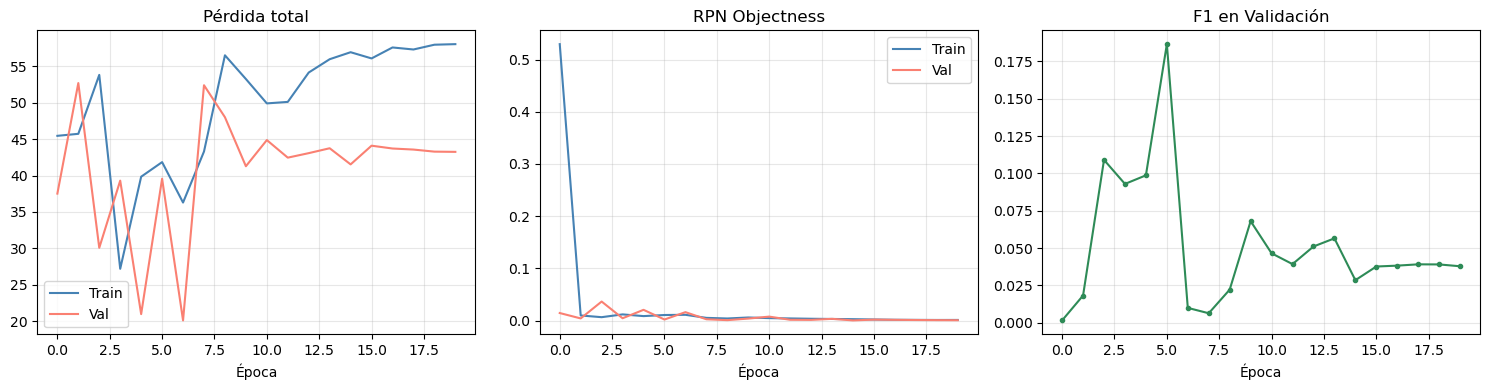

In [22]:
import pandas as pd

log = pd.read_csv(os.path.join(RESULT_DIR, 'log.csv'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(log['epoch'], log['train_total'], label='Train', color='steelblue')
axes[0].plot(log['epoch'], log['val_total'],   label='Val',   color='salmon')
axes[0].set_title('Pérdida total'); axes[0].set_xlabel('Época')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(log['epoch'], log['train_objectness'], label='Train', color='steelblue')
axes[1].plot(log['epoch'], log['val_objectness'],   label='Val',   color='salmon')
axes[1].set_title('RPN Objectness'); axes[1].set_xlabel('Época')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(log['epoch'], log['f1'], color='seagreen', marker='o', markersize=3)
axes[2].set_title('F1 en Validación'); axes[2].set_xlabel('Época')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join('.', 'training_curves.png'), dpi=120)
plt.show()

## 8. Visualización de predicciones

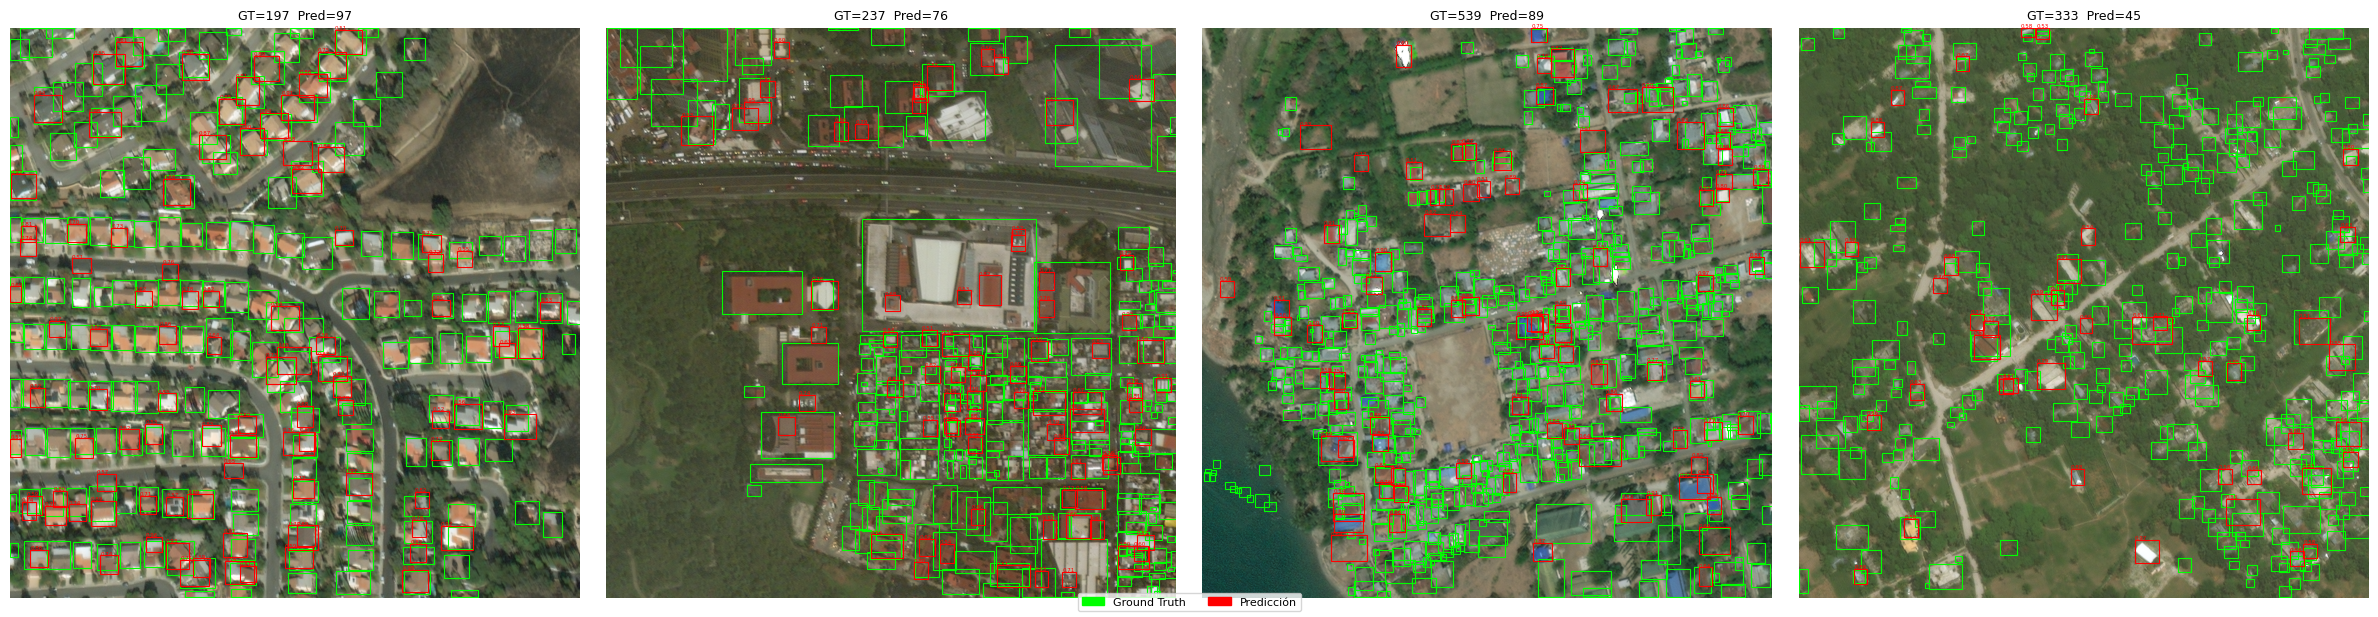

In [21]:
def visualize_predictions(model, dataset, num_images=4, th_score=0.5):
    model.eval()
    indices = np.random.choice(len(dataset), min(num_images, len(dataset)), replace=False)

    fig, axes = plt.subplots(1, len(indices), figsize=(6 * len(indices), 6))
    if len(indices) == 1:
        axes = [axes]

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            img, tgt, path = dataset[idx]
            pred = model([img.to(DEVICE)])[0]

            # Imagen en RGB
            vis = img.permute(1, 2, 0).numpy()
            vis = np.clip(vis, 0, 1)
            ax.imshow(vis)

            # GT (verde)
            for box in tgt['boxes']:
                x1, y1, x2, y2 = box.tolist()
                rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                          linewidth=0.8, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)

            # Predicciones (rojo)
            keep = pred['scores'].cpu() > th_score
            for box, sc in zip(pred['boxes'].cpu()[keep], pred['scores'].cpu()[keep]):
                x1, y1, x2, y2 = box.tolist()
                rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                          linewidth=0.8, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1-1, f'{sc:.2f}', color='red', fontsize=4)

            n_gt   = len(tgt['boxes'])
            n_pred = keep.sum().item()
            ax.set_title(f'GT={n_gt}  Pred={n_pred}', fontsize=9)
            ax.axis('off')

    green_patch = mpatches.Patch(color='lime', label='Ground Truth')
    red_patch   = mpatches.Patch(color='red',  label='Predicción')
    fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join('.', 'predictions_vis.png'), dpi=150)
    plt.show()


visualize_predictions(model, dataset_test, num_images=4, th_score=TH_SCORE)